# <center> Feature Engineering </center>
# <center> Ingeniería de características </center>

Links de interés

https://pandas.pydata.org

Importamos las librerías que vamos a utilizar

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## <center> Normalización </center>
<br>
Es útil en:<br>
 - Tareas donde las unidades de medidas dificultan la comparación entre features.<br>
 - Medidas de distancias. Vecinos más cercanos, Clustering, etc.<br>
 - Para evitar que los atributos con mayores magnitudes tengan mayor peso que los rangos pequeño.<br>

### Min-Max

La normalización Min-Max escala las características a un rango que por lo general es [0, 1]. <br> Esta técnica es útil cuando los datos tienen diferentes rangos de valores y queremos que todas las características contribuyan de manera equitativa al modelo de aprendizaje.

La fórmula para normalizar un valor \( x \) usando el método Min-Max en un rango \([a, b]\) es:

$$
x_{\text{norm}} = a + \frac{(x - x_{\text{min}}) \cdot (b - a)}{x_{\text{max}} - x_{\text{min}}}
$$

donde:

- x es el valor original.
- $x_{\text{min}}$  es el valor mínimo en el conjunto de datos.
- $x_{\text{max}}$ es el valor máximo en el conjunto de datos.
- a es el límite inferior del nuevo rango.
- b es el límite superior del nuevo rango.
- $x_{\text{norm}}$ es el valor normalizado.

En general b=1 y a =0 quedando

$$
x_{\text{norm}} =\frac{x - x_{\text{min}} }{x_{\text{max}} - x_{\text{min}}}
$$


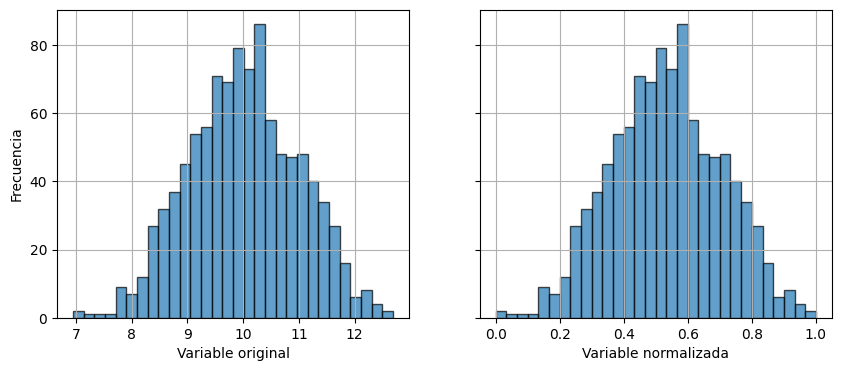

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Crear un conjunto de datos de ejemplo
data = { 'x1': np.random.normal(10, 1, 1000) }
df = pd.DataFrame(data)

# Inicializar el objeto MinMaxScaler con un rango [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Aplicar la normalización Min-Max
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(10)
#Subplot 1
ax1.hist(df.x1, bins=30, edgecolor='k', alpha=0.7)
ax1.set(xlabel='Variable original', ylabel='Frecuencia')
ax1.grid(True)
ax1.label_outer()
#Subplot 2
ax2.hist(df_normalized.x1, bins=30, edgecolor='k', alpha=0.7)
ax2.set(xlabel='Variable normalizada', ylabel='Frecuencia')
ax2.grid(True)
ax2.label_outer()

plt.show()

In [ ]:
scaler.fit(df_train)

df_train_normalized = pd.DataFrame(scaler.transform(df_train), columns=df_train.columns)

df_test_normalized = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)

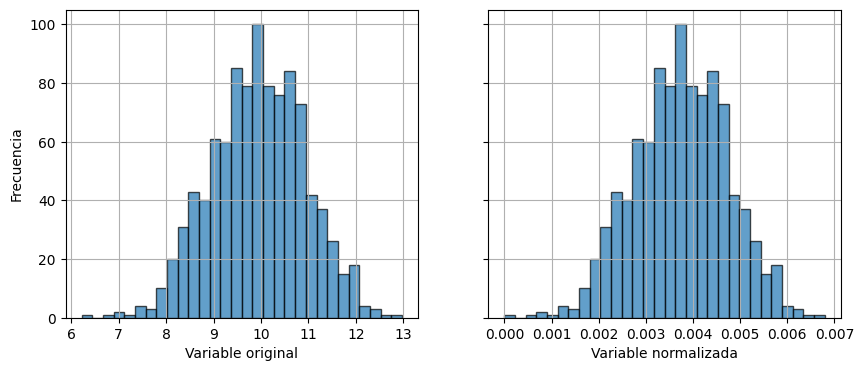

In [11]:

# Crear un conjunto de datos de ejemplo
n=np.random.normal(10, 1, 1000)
outliers=[1000]
n=np.append(n,outliers)
data = { 'x1': n }
df = pd.DataFrame(data)

# Inicializar el objeto MinMaxScaler con un rango [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Aplicar la normalización Min-Max
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(10)
#Subplot 1
ax1.hist(df.x1[0:1000], bins=30, edgecolor='k', alpha=0.7)
ax1.set(xlabel='Variable original', ylabel='Frecuencia')
ax1.grid(True)
ax1.label_outer()
#Subplot 2
ax2.hist(df_normalized.x1[0:1000], bins=30, edgecolor='k', alpha=0.7)
ax2.set(xlabel='Variable normalizada', ylabel='Frecuencia')
ax2.grid(True)
ax2.label_outer()

plt.show()

### Z-score

Indica cuántas desviaciones estándar está un punto de datos por encima o por debajo de la media de un conjunto de datos.
Tiene sentido en el caso que la media y el desvío resulten una buena representación de la centralidad y la dispersión.

Sensibilidad a Outliers: Sensible a valores atípicos (outliers). Técnicas robustas como la mediana absoluta de desviación mediana (MAD)

$$
Z = \frac{x - \mu}{\sigma}
$$

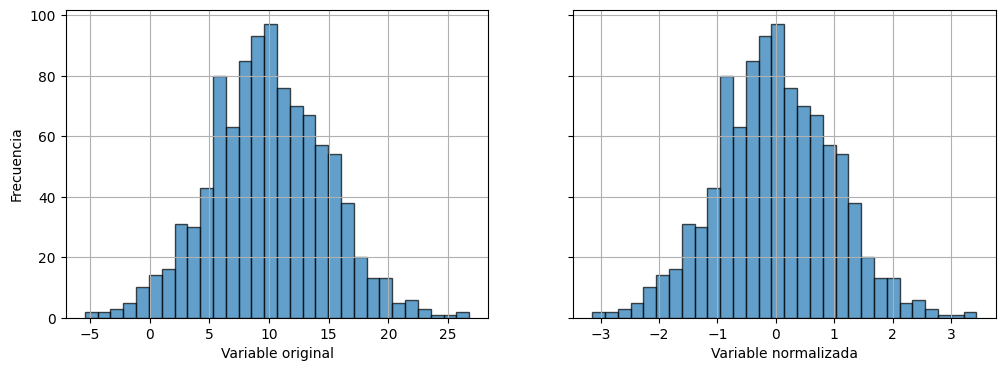

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Crear un conjunto de datos de ejemplo
data = { 'x1': np.random.normal(10, 5, 1000) }
df = pd.DataFrame(data)

scaler = StandardScaler()

# Aplicar la normalización Z-score
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(12)
#Subplot 1
ax1.hist(df.x1, bins=30, edgecolor='k', alpha=0.7)
ax1.set(xlabel='Variable original', ylabel='Frecuencia')
ax1.grid(True)
ax1.label_outer()
#Subplot 2
ax2.hist(df_normalized.x1, bins=30, edgecolor='k', alpha=0.7)
ax2.set(xlabel='Variable normalizada', ylabel='Frecuencia')
ax2.grid(True)
ax2.label_outer()

plt.show()

In [ ]:
df_train
df_test

scaler.fit(df_train)

df_train_normalized = pd.DataFrame(scaler.transform(df_train), columns=df_train.columns)

df_test_normalized = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)

Vemos que pasa con outliers

(array([ 2.,  2.,  3.,  5., 10., 14., 16., 31., 30., 43., 80., 63., 85.,
        93., 97., 76., 70., 67., 57., 54., 38., 20., 13., 13.,  5.,  6.,
         3.,  1.,  1.,  2.]),
 array([-5.42712847, -4.35411743, -3.28110638, -2.20809533, -1.13508428,
        -0.06207323,  1.01093782,  2.08394886,  3.15695991,  4.22997096,
         5.30298201,  6.37599306,  7.44900411,  8.52201516,  9.5950262 ,
        10.66803725, 11.7410483 , 12.81405935, 13.8870704 , 14.96008145,
        16.03309249, 17.10610354, 18.17911459, 19.25212564, 20.32513669,
        21.39814774, 22.47115879, 23.54416983, 24.61718088, 25.69019193,
        26.76320298]),
 <BarContainer object of 30 artists>)

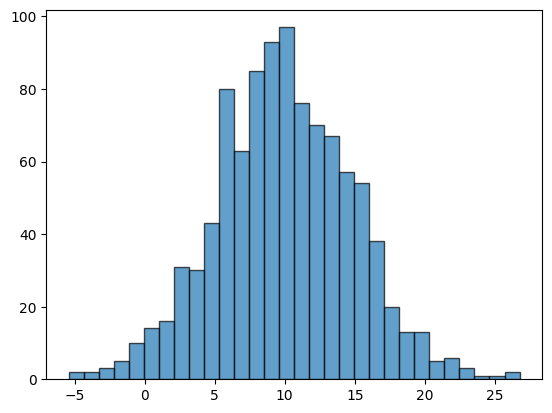

In [15]:
df_orig_inverse = pd.DataFrame(scaler.inverse_transform(df_normalized), columns=df.columns)

plt.hist(df_orig_inverse.x1, bins=30, edgecolor='k', alpha=0.7)

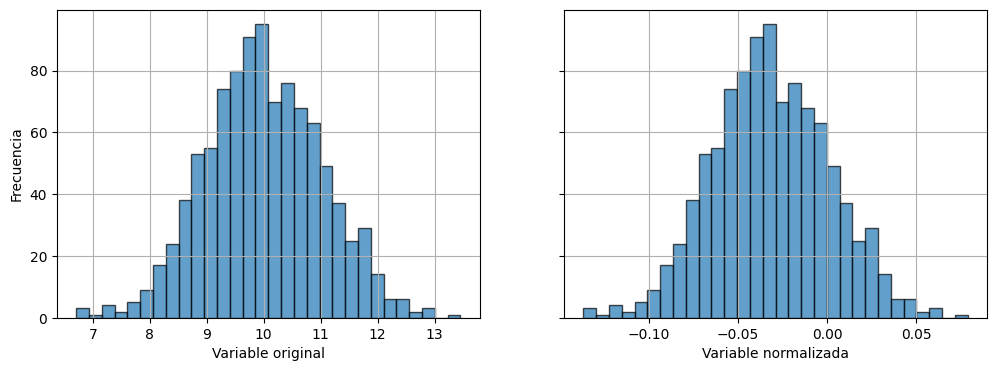

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Crear un conjunto de datos de ejemplo
n=np.random.normal(10, 1, 1000)
outliers=[1000]
n=np.append(n,outliers)
data = { 'x1': n }
df = pd.DataFrame(data)

scaler = StandardScaler()

# Aplicar la normalización Min-Max
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(12)
#Subplot 1
ax1.hist(df.x1[0:(df.shape[0]-len(outliers))], bins=30, edgecolor='k', alpha=0.7)
ax1.set(xlabel='Variable original', ylabel='Frecuencia')
ax1.grid(True)
ax1.label_outer()
#Subplot 2
ax2.hist(df_normalized.x1[0:(df.shape[0]-len(outliers))], bins=30, edgecolor='k', alpha=0.7)
ax2.set(xlabel='Variable normalizada', ylabel='Frecuencia')
ax2.grid(True)
ax2.label_outer()

plt.show()

### Escalado robusto

Escala los datos utilizando la mediana y el rango intercuartílico (IQR) en lugar de la media y la desviación estándar, lo que lo hace más robusto frente a outliers.

$$
X_{\text{escalada}} = \frac{X - \text{mediana}(X)}{Q3(X) - Q1(X)}
$$

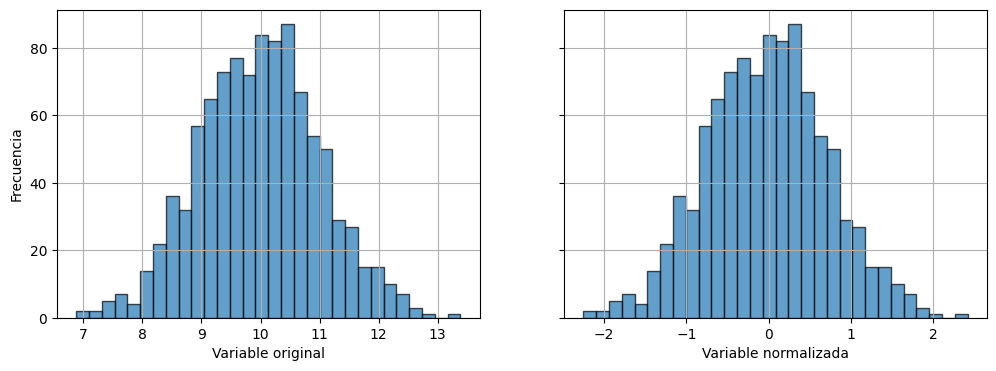

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# Crear un conjunto de datos de ejemplo
n=np.random.normal(10, 1, 1000)
outliers=[1000]
n=np.append(n,outliers)
data = { 'x1': n }
df = pd.DataFrame(data)

scaler = RobustScaler()

# Aplicar la normalización Min-Max
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(12)
#Subplot 1
ax1.hist(df.x1[0:(df.shape[0]-len(outliers))], bins=30, edgecolor='k', alpha=0.7)
ax1.set(xlabel='Variable original', ylabel='Frecuencia')
ax1.grid(True)
ax1.label_outer()
#Subplot 2
ax2.hist(df_normalized.x1[0:(df.shape[0]-len(outliers))], bins=30, edgecolor='k', alpha=0.7)
ax2.set(xlabel='Variable normalizada', ylabel='Frecuencia')
ax2.grid(True)
ax2.label_outer()

plt.show()

In [ ]:
df_train
df_test

scaler.fit(df_train)

df_train_normalized = pd.DataFrame(scaler.transform(df_train), columns=df_train.columns)

df_test_normalized = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)



### Box-Cox

Técnica utilizada para transformar variables que no siguen una distribución normal en variables que se asemejan más a una distribución normal

$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(y) & \text{si } \lambda = 0 \end{cases}$

Donde:
- $y$ es la variable original que queremos transformar.
- $\lambda$ es el parámetro de transformación que se determina empíricamente para maximizar la normalidad de los datos transformados.
- Para $\lambda \neq 0$, se utiliza la transformación $\frac{y^\lambda - 1}{\lambda}$.
- Para $\lambda = 0$, se aplica la transformación $\ln(y)$, equivalente a una transformación logarítmica natural.

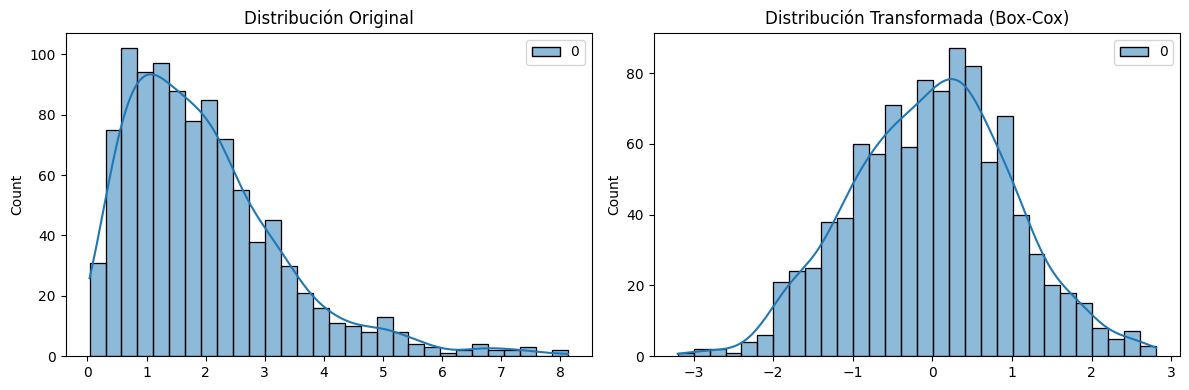

In [ ]:
import numpy as np
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# Generar datos con una distribución sesgada (gamma)
np.random.seed(0)
X = np.random.gamma(2, 1, 1000).reshape(-1, 1)

# Visualizar la distribución original
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(X, bins=30, kde=True)
plt.title('Distribución Original')

# Aplicar la transformación Box-Cox
boxcox_transformer = PowerTransformer(method='box-cox')
X_transformed = boxcox_transformer.fit_transform(X)

# Visualizar la distribución transformada
plt.subplot(1, 2, 2)
sns.histplot(X_transformed, bins=30, kde=True)
plt.title('Distribución Transformada (Box-Cox)')
plt.tight_layout()

### Decimal Scaling

In [ ]:
def decimal_scaling(feature):
    max_value = np.max(np.abs(feature))
    scaling_factor = 10 ** np.ceil(np.log10(max_value))
    scaled_data = feature / scaling_factor
    return scaled_data

n=np.random.normal(10, 1, 1000)
data = { 'x1': n }
df = pd.DataFrame(data)

# Aplicamos decimal scaling a nuestro DataFrame
df["scaled_feature"] = decimal_scaling(df.x1)
print("\nDatos escalados usando decimal scaling:")
df.head()


Datos escalados usando decimal scaling:


,x1,scaled_feature
0,8.889099,0.088891
1,10.217471,0.102175
2,10.054060,0.100541
3,9.908807,0.099088
4,10.009817,0.100098


## <center> Numéricas a categóricas </center>

### Binning

Agrupa valores numéricos en intervalos discretos (bins).<br>
Puede ser útil para reducir el efecto de ruido y outliers.

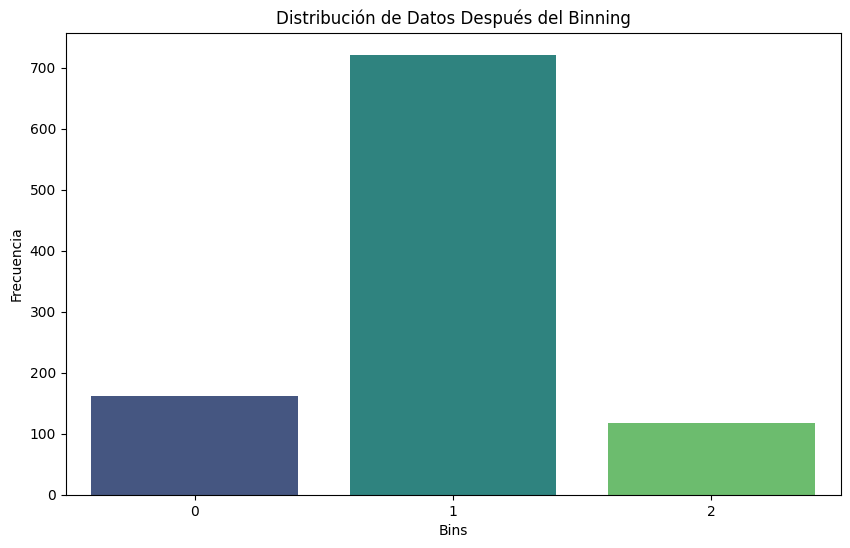

In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
import seaborn as sns

# Generar un conjunto de datos ficticio con distribución normal
# Generamos 1000 muestras de una distribución normal con media 10 y desviación estándar 1
X = np.random.normal(10, 1, 1000).reshape(-1, 1)  # Reshape para tener una columna

# Crear un objeto KBinsDiscretizer
# Especificamos el número de bins y la estrategia de agrupación ('uniform' para bins de igual ancho)
n_bins = 3  # Número de bins
binning_model = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')

# Ajustar el modelo y transformar los datos
X_binned = binning_model.fit_transform(X)

# Contar frecuencias en cada bin
bin_counts = np.bincount(X_binned.flatten().astype(int))

#Gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(n_bins), y=bin_counts, palette='viridis')
plt.title('Distribución de Datos Después del Binning')
plt.xlabel('Bins')
plt.ylabel('Frecuencia')
plt.xticks(np.arange(n_bins), [i for i in range(n_bins)])
plt.show()

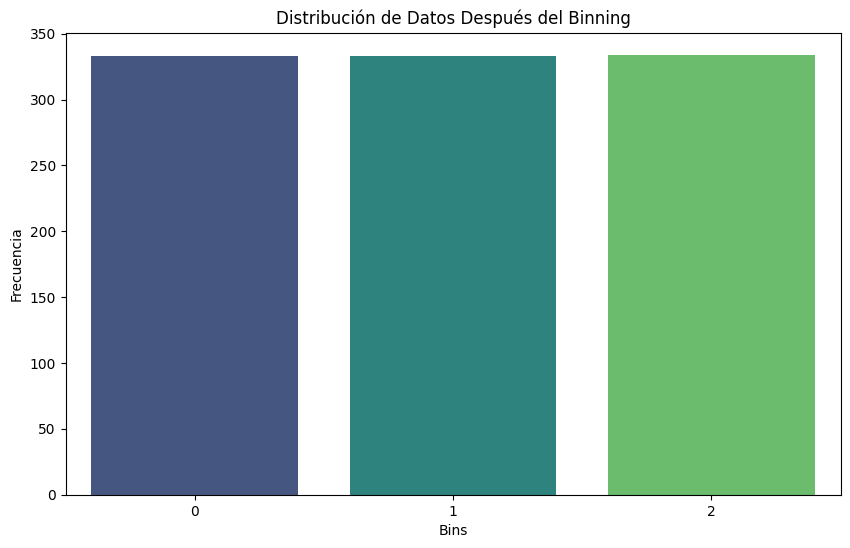

In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
import seaborn as sns

# Generar un conjunto de datos ficticio con distribución normal
# Generamos 1000 muestras de una distribución normal con media 10 y desviación estándar 1
X = np.random.normal(10, 1, 1000).reshape(-1, 1)  # Reshape para tener una columna

# Crear un objeto KBinsDiscretizer
# Especificamos el número de bins y la estrategia de agrupación ('quantile' para bins tengan igual frecuencia)
n_bins = 3  # Número de bins
binning_model = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')

# Ajustar el modelo y transformar los datos
X_binned = binning_model.fit_transform(X)

# Contar frecuencias en cada bin
bin_counts = np.bincount(X_binned.flatten().astype(int))

#Gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(n_bins), y=bin_counts, palette='viridis')
plt.title('Distribución de Datos Después del Binning')
plt.xlabel('Bins')
plt.ylabel('Frecuencia')
plt.xticks(np.arange(n_bins), [i for i in range(n_bins)])
plt.show()

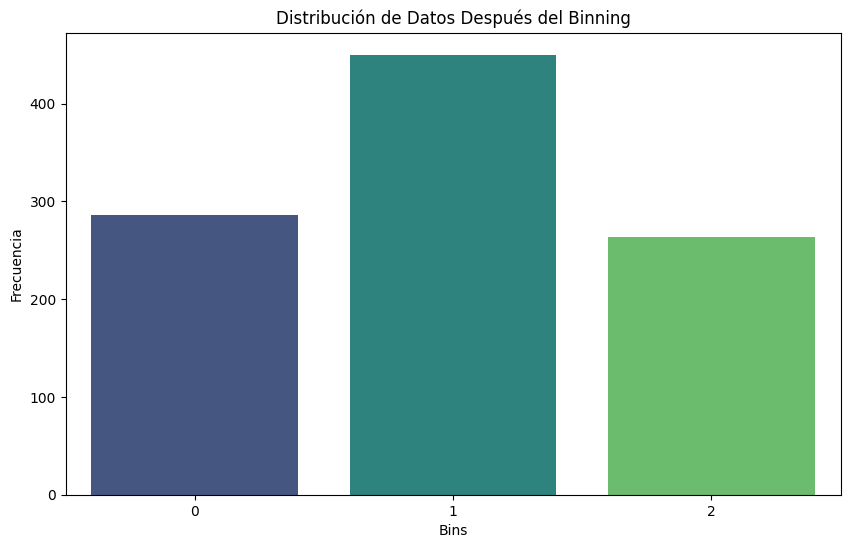

In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
import seaborn as sns

# Generar un conjunto de datos ficticio con distribución normal
# Generamos 1000 muestras de una distribución normal con media 10 y desviación estándar 1
X = np.random.normal(10, 1, 1000).reshape(-1, 1)  # Reshape para tener una columna

# Crear un objeto KBinsDiscretizer
# Especificamos el número de bins y la estrategia de agrupación ('kmeans' K-means para encontrar bins de igual varianza)
n_bins = 3  # Número de bins
binning_model = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans')

# Ajustar el modelo y transformar los datos
X_binned = binning_model.fit_transform(X)

# Contar frecuencias en cada bin
bin_counts = np.bincount(X_binned.flatten().astype(int))

#Gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(n_bins), y=bin_counts, palette='viridis')
plt.title('Distribución de Datos Después del Binning')
plt.xlabel('Bins')
plt.ylabel('Frecuencia')
plt.xticks(np.arange(n_bins), [i for i in range(n_bins)])
plt.show()

### One-Hot Encoding

Transforma características categóricas en un vector binario con un 1 en la posición correspondiente a la categoría y 0 en todas las demás posiciones.

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Ejemplo de datos con características categóricas
categorias = np.array(['gato', 'perro', 'pájaro', 'perro', 'gato'])

# Crear un objeto OneHotEncoder
encoder = OneHotEncoder()

# Ajustar y transformar los datos
categorias_encoded = encoder.fit_transform(categorias.reshape(-1, 1))

# Mostrar resultados
print("Datos originales:")
print(categorias)
print("\nDatos codificados con OneHotEncoder:")
print(categorias_encoded.toarray())
print("\nCategorías mapeadas:")
print(encoder.categories_)

Datos originales:
['gato' 'perro' 'pájaro' 'perro' 'gato']

Datos codificados con OneHotEncoder:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Categorías mapeadas:
[array(['gato', 'perro', 'pájaro'], dtype='<U6')]
